In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset del Dólar
df_dolar = pd.read_csv('dolar_data.csv')

print("--- 1. INFORMACIÓN GENERAL DEL DATASET ---")
print(df_dolar.info())
print("\n--- 2. PRIMERAS FILAS ---")
display(df_dolar.head())

print("\n--- 3. VERIFICACIÓN DE VALORES NULOS Y DUPLICADOS ---")
print("Nulos por columna:\n", df_dolar.isnull().sum())
print("Filas duplicadas:", df_dolar.duplicated().sum())

print("\n--- 4. ESTADÍSTICAS DESCRIPTIVAS Y RANGOS ---")
display(df_dolar.describe())

--- 1. INFORMACIÓN GENERAL DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Dia           500 non-null    int64  
 1   Inflacion     500 non-null    float64
 2   Tasa_interes  500 non-null    float64
 3   Precio_Dolar  500 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 15.8 KB
None

--- 2. PRIMERAS FILAS ---


,Dia,Inflacion,Tasa_interes,Precio_Dolar
0,1,0.022484,5.463089,4024.833598
1,2,0.019309,5.954708,4000.546337
2,3,0.023238,4.300716,3979.622045
3,4,0.027615,5.281485,3940.361345
4,5,0.018829,4.674679,4016.930225



--- 3. VERIFICACIÓN DE VALORES NULOS Y DUPLICADOS ---
Nulos por columna:
 Dia             0
Inflacion       0
Tasa_interes    0
Precio_Dolar    0
dtype: int64
Filas duplicadas: 0

--- 4. ESTADÍSTICAS DESCRIPTIVAS Y RANGOS ---


,Dia,Inflacion,Tasa_interes,Precio_Dolar
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,0.020034,5.015913,5211.771934
std,144.481833,0.004906,0.488999,723.895212
min,1.000000,0.003794,3.651557,3940.361345
25%,125.750000,0.016498,4.702354,4604.884954
50%,250.500000,0.020064,5.014266,5218.791143
75%,375.250000,0.023184,5.325621,5825.235279
max,500.000000,0.039264,6.316191,6553.598583


In [12]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset original
df_dolar = pd.read_csv('dolar_data.csv')

print("=== FASE DE LIMPIEZA Y PREPARACIÓN DE DATOS (CRISP-DM) ===")
print(f"1. Total de registros iniciales: {len(df_dolar)}")

# 2. Verificar y tratar valores nulos
nulos = df_dolar.isnull().sum().sum()
print(f"2. Valores nulos encontrados: {nulos}")
if nulos > 0:
    df_dolar = df_dolar.dropna()
    print("   -> Se eliminaron los registros nulos.")
else:
    print("   -> No se requirió imputación ni eliminación de nulos.")

# 3. Verificar duplicados
duplicados = df_dolar.duplicated().sum()
print(f"3. Registros duplicados encontrados: {duplicados}")
if duplicados > 0:
    df_dolar = df_dolar.drop_duplicates()
    print("   -> Se eliminaron los registros duplicados.")
else:
    print("   -> El dataset no contiene filas duplicadas.")

# 4. Auditoría y EXCLUSIÓN formal de valores atípicos (Outliers) mediante IQR
print("4. Auditoría y Filtrado de Outliers:")
cols_a_filtrar = ['Inflacion', 'Tasa_interes', 'Precio_Dolar']
mask = pd.Series(True, index=df_dolar.index)

for col in cols_a_filtrar:
    Q1 = df_dolar[col].quantile(0.25)
    Q3 = df_dolar[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers_count = ((df_dolar[col] < lim_inf) | (df_dolar[col] > lim_sup)).sum()
    print(f"   - Variable '{col}': {outliers_count} atípicos detectados fuera de [{lim_inf:.4f}, {lim_sup:.4f}]")
    # Aplicar máscara para excluir outliers
    mask &= (df_dolar[col] >= lim_inf) & (df_dolar[col] <= lim_sup)

# Excluir formalmente los outliers del dataframe de trabajo
df_dolar = df_dolar[mask].reset_index(drop=True)

print(f"\n¡Dataset depurado! Total de registros finales limpios: {len(df_dolar)}")

=== FASE DE LIMPIEZA Y PREPARACIÓN DE DATOS (CRISP-DM) ===
1. Total de registros iniciales: 500
2. Valores nulos encontrados: 0
   -> No se requirió imputación ni eliminación de nulos.
3. Registros duplicados encontrados: 0
   -> El dataset no contiene filas duplicadas.
4. Auditoría y Filtrado de Outliers:
   - Variable 'Inflacion': 4 atípicos detectados fuera de [0.0065, 0.0332]
   - Variable 'Tasa_interes': 7 atípicos detectados fuera de [3.7675, 6.2605]
   - Variable 'Precio_Dolar': 0 atípicos detectados fuera de [2774.3595, 7655.7608]

¡Dataset depurado! Total de registros finales limpios: 490


--- RESULTADOS DEL MODELO DE REGRESIÓN LINEAL (DÓLAR - DATOS LIMPIOS) ---
Intercepto (b0): 3981.5309
Coeficiente para Dia (b): 4.9979
Coeficiente para Inflacion (b): -572.6503
Coeficiente para Tasa_interes (b): -2.2239
Error Medio Cuadrático (MSE): 2560.4973
Coeficiente de Determinación (R²): 0.9959


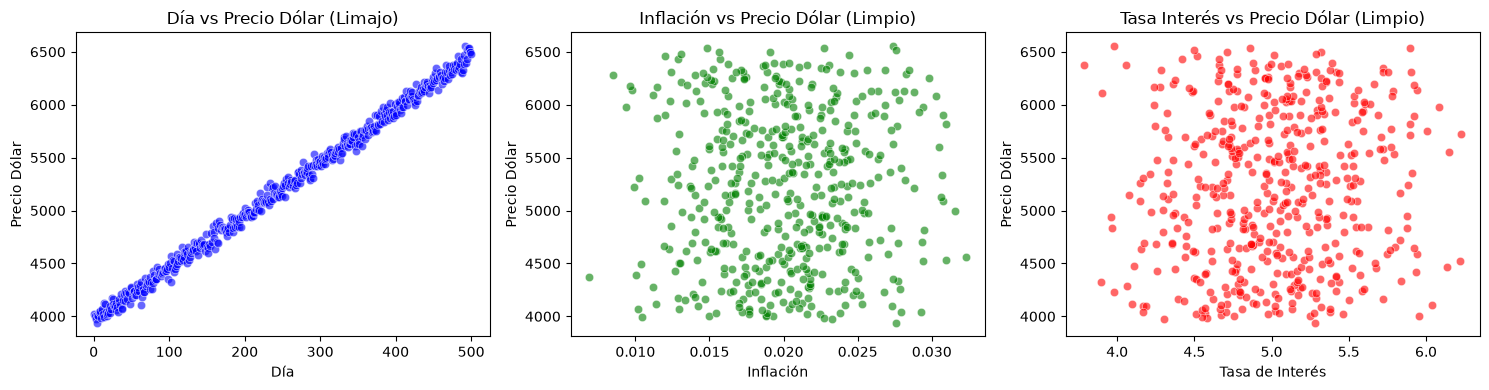

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separar Variables Independientes (X) y Variable Dependiente (y)
X = df_dolar[['Dia', 'Inflacion', 'Tasa_interes']]
y = df_dolar['Precio_Dolar']

# 2. Dividir en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Ajustar / Entrenar el Modelo de Regresión Lineal Múltiple con datos limpios
modelo_dolar = LinearRegression()
modelo_dolar.fit(X_train, y_train)

# 4. Realizar Predicciones sobre el conjunto de prueba
y_pred = modelo_dolar.predict(X_test)

# 5. Evaluar el Desempeño
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- RESULTADOS DEL MODELO DE REGRESIÓN LINEAL (DÓLAR - DATOS LIMPIOS) ---")
print(f"Intercepto (b0): {modelo_dolar.intercept_:.4f}")
for col, coef in zip(X.columns, modelo_dolar.coef_):
    print(f"Coeficiente para {col} (b): {coef:.4f}")
print(f"Error Medio Cuadrático (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

# 6. Gráficas de relación con el dataset limpio
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(x=df_dolar['Dia'], y=df_dolar['Precio_Dolar'], alpha=0.6, color='b')
plt.title('Día vs Precio Dólar (Limajo)')
plt.xlabel('Día')
plt.ylabel('Precio Dólar')

plt.subplot(1, 3, 2)
sns.scatterplot(x=df_dolar['Inflacion'], y=df_dolar['Precio_Dolar'], alpha=0.6, color='g')
plt.title('Inflación vs Precio Dólar (Limpio)')
plt.xlabel('Inflación')
plt.ylabel('Precio Dólar')

plt.subplot(1, 3, 3)
sns.scatterplot(x=df_dolar['Tasa_interes'], y=df_dolar['Precio_Dolar'], alpha=0.6, color='r')
plt.title('Tasa Interés vs Precio Dólar (Limpio)')
plt.xlabel('Tasa de Interés')
plt.ylabel('Precio Dólar')

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import joblib

# 1. Exportar / Guardar el modelo entrenado con datos limpios
nombre_archivo_modelo = 'modelo_dolar.pkl'
joblib.dump(modelo_dolar, nombre_archivo_modelo)
print(f"¡Modelo limpio exportado exitosamente como '{nombre_archivo_modelo}'!")

# 2. Cargar el modelo y realizar una predicción de prueba usando un DataFrame
modelo_cargado = joblib.load(nombre_archivo_modelo)

# Datos de prueba con los nombres exactos de las columnas
datos_nuevo_dia = pd.DataFrame(
    [[501, 0.0200, 5.0000]], 
    columns=['Dia', 'Inflacion', 'Tasa_interes']
)

prediccion_prueba = modelo_cargado.predict(datos_nuevo_dia)

print("\n--- PRUEBA DE CARGA Y PREDICCIÓN (MODELO LIMPIO) ---")
print(f"Datos ingresados -> Día: 501, Inflación: 2.0%, Tasa de Interés: 5.0%")
print(f"Precio del Dólar predicho: {prediccion_prueba[0]:.4f}")

¡Modelo limpio exportado exitosamente como 'modelo_dolar.pkl'!

--- PRUEBA DE CARGA Y PREDICCIÓN (MODELO LIMPIO) ---
Datos ingresados -> Día: 501, Inflación: 2.0%, Tasa de Interés: 5.0%
Precio del Dólar predicho: 6462.9242
